In [1]:
import os
import sys
sys.path.insert(0, '/home/aiscuser/verl')
import torch
from verl.third_party.sglang.entrypoint import CustomEngine
from verl.utils.dataset.rl_dataset import RLHFDataset, collate_fn
os.environ["SGLANG_BLOCK_NONZERO_RANK_CHILDREN"] = "0"
from transformers import AutoTokenizer, AutoProcessor
from uuid import uuid4

/opt/conda/envs/ptca/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-05-10 10:39:00,236	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


INFO 05-10 10:39:01 __init__.py:190] Automatically detected platform rocm.
WARNING 05-10 10:39:01 rocm.py:33] `fork` method is not supported by ROCm. VLLM_WORKER_MULTIPROC_METHOD is overridden to `spawn` instead.


In [2]:
engine = CustomEngine(
    model_path='/tmp/Llama3.1-8B-step320-merged',
    dtype=torch.bfloat16,
    mem_fraction_static=0.4,
    base_gpu_id=0,
    gpu_id_step=1,
    max_running_requests=128,
    cuda_graph_max_bs=128,
    tp_size=4,
    enable_mixed_chunk=True,
    node_rank=0,
    stream_interval=256,
    nnodes=1,
    enable_torch_compile=False,
)


INFO 05-10 10:39:11 __init__.py:190] Automatically detected platform rocm.
INFO 05-10 10:39:11 __init__.py:190] Automatically detected platform rocm.
INFO 05-10 10:39:11 __init__.py:190] Automatically detected platform rocm.
INFO 05-10 10:39:11 __init__.py:190] Automatically detected platform rocm.
INFO 05-10 10:39:11 __init__.py:190] Automatically detected platform rocm.
node-0:52173:52173 [0] NCCL INFO Bootstrap : Using eth0:100.64.152.128<0>
node-0:52173:52173 [0] NCCL INFO NET/Plugin : dlerror=librccl-net.so: cannot open shared object file: No such file or directory No plugin found (librccl-net.so), using internal implementation
node-0:52173:52173 [0] NCCL INFO Kernel version: 5.15.0-1073-azure
node-0:52173:52173 [0] NCCL INFO ROCr version 1.14
node-0:52173:52173 [0] NCCL INFO Dmabuf feature disabled without NCCL_DMABUF_ENABLE=1
RCCL version 2.20.5+hip6.2 HEAD:45b618a+
node-0:52175:52175 [2] NCCL INFO ROCr version 1.14
node-0:52174:52174 [1] NCCL INFO ROCr version 1.14
node-0:52175

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  25% Completed | 1/4 [00:00<00:00,  8.63it/s]
Loading safetensors checkpoint shards:  50% Completed | 2/4 [00:00<00:00,  3.15it/s]
Loading safetensors checkpoint shards:  75% Completed | 3/4 [00:01<00:00,  2.12it/s]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:01<00:00,  1.89it/s]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:01<00:00,  2.17it/s]

100%|██████████| 19/19 [00:09<00:00,  2.07it/s]


In [4]:
import asyncio
from typing import List, Dict, Optional, Union
from sglang.srt.managers.io_struct import GenerateReqInput, AbortReq
from sglang.srt.entrypoints.verl_engine import VerlEngine as VerlEngineBase
from sglang.srt.entrypoints.verl_engine import _preprocess_tensor_for_update_weights
from sglang.srt.server import Engine
from sglang.srt.utils import MultiprocessingSerializer, broadcast_pyobj
from sglang.srt.model_executor.model_runner import LocalSerializedTensor
import time

async def get_first_value(async_gen):
    return await async_gen.__anext__()

async def get_first_n_results(self, tasks, num_returns):
    outputs = {}
    completed_oids = []
    completed_rids = []
    all_tasks = [task for task_dict in tasks.values() for task in task_dict.values()]
    for oid in tasks.keys():
        outputs[oid] = {}

    queue_stat = []
    for task in asyncio.as_completed(all_tasks):
        result = await task
        rid = result['meta_info']['id']
        oid = rid.split('_nid')[0]
        outputs[oid][rid] = result
        completed_rids.append(rid)
        tasks[oid].pop(rid)
        queue_stat.append((time.time(), num_returns - len(completed_rids)))
        if len(tasks[oid].keys()) == 0:
            completed_oids.append(oid)
            tasks.pop(oid)
        if len(completed_oids) >= num_returns:
            break

    for oid, task_dict in tasks.items():
        for rid in task_dict.keys():
            self.tokenizer_manager.abort_request(rid)



    # Wait for idle
    while True:
        # print(f'waiting for idle')
        internal_state = await self.tokenizer_manager.get_internal_state()
        if internal_state['is_idle']:
            # print(f'idle')
            break
    
    # Scavenge incomplete results
    incomplete_tasks = [task for task_dict in tasks.values() for task in task_dict.values()]



    await asyncio.sleep(1)
    for task in incomplete_tasks:
        if task.done():
            result = await task
            incomplete_tasks.remove(task)
            rid = result['meta_info']['id']
            oid = rid.split('_nid')[0]
            outputs[oid][rid] = result
            finish_reason = result['meta_info'].get('finish_reason', {type: ''})
            # to_delete_rids.remove(rid)
            if finish_reason['type'] != 'abort':
                completed_rids.append(rid)
                tasks[oid].pop(rid)
                if len(tasks[oid].keys()) == 0:
                    completed_oids.append(oid)
                    tasks.pop(oid)
        else:
            task.cancel()

    partial_outputs = self.gather_partial_outputs()

    self.tokenizer_manager.clear_queue()
    for output in partial_outputs:
        rid = output['meta_info']['id']
        oid = rid.split('_nid')[0]
        outputs[oid][rid] = output

    return outputs, queue_stat

def custom_generate(
    self,
    # The input prompt. It can be a single prompt or a batch of prompts.
    prompt: Optional[List[str]] = None,
    sampling_params: Optional[Union[List[Dict], Dict]] = None,
    # The token ids for text; one can either specify text or input_ids.
    input_ids: Optional[Union[List[List[int]], List[int]]] = None,
    # The image input. It can be a file name, a url, or base64 encoded string.
    # See also python/sglang/srt/utils.py:load_image.
    image_data: Optional[Union[List[str], str]] = None,
    return_logprob: Optional[Union[List[bool], bool]] = False,
    logprob_start_len: Optional[Union[List[int], int]] = None,
    top_logprobs_num: Optional[Union[List[int], int]] = None,
    token_ids_logprob: Optional[Union[List[List[int]], List[int]]] = None,
    lora_path: Optional[List[Optional[str]]] = None,
    custom_logit_processor: Optional[Union[List[str], str]] = None,
    stream: bool = False,
    rid: Optional[Union[List[str], str]] = None,
    num_returns: Optional[int] = None,
) -> Union[Dict]:
    if prompt is not None:
        batch_size = len(prompt)
    if input_ids is not None:
        batch_size = len(input_ids)
    loop = asyncio.get_event_loop()
    
    n = sampling_params.get("n", 1) if sampling_params is not None else 1
    sampling_params_ = sampling_params.copy()
    sampling_params_['n'] = 1
    assert num_returns is not None, "num_returns should be provided"
    assert rid is not None, "rid should be provided"

    original_rids = list(set([rid.split('_nid')[0] for rid in rid]))
    all_rids = rid


    objs = {}
    tasks = {}
    for oid in original_rids:
        objs[oid] = {}
        tasks[oid] = {}
    for i, rid in enumerate(all_rids):
        oid = rid.split('_nid')[0]
        tmp_sampling_params = sampling_params_.copy()
        max_new_tokens = sampling_params_.get('max_new_tokens', 16*1024)
        max_length = 18 * 1024
        context_length = len(input_ids[i])
        max_new_tokens = min(max_new_tokens, max_length - context_length)
        max_new_tokens = max(max_new_tokens, 1)
        tmp_sampling_params['max_new_tokens'] = max_new_tokens
        objs[oid][rid] = GenerateReqInput(
            text=None,
            input_ids=input_ids[i],
            sampling_params=tmp_sampling_params,
            image_data=None,
            return_logprob=return_logprob,
            logprob_start_len=logprob_start_len,
            top_logprobs_num=top_logprobs_num,
            token_ids_logprob=token_ids_logprob,
            lora_path=lora_path,
            custom_logit_processor=custom_logit_processor,
            stream=False,
            rid=rid,
        )
        generator = self.tokenizer_manager.generate_request(objs[oid][rid], None)
        task = loop.create_task(get_first_value(generator))
        tasks[oid][rid] = task



    outputs, queue_stat = loop.run_until_complete(self.get_first_n_results(tasks, num_returns))

    return outputs, queue_stat

engine.custom_generate = custom_generate.__get__(engine, CustomEngine)
engine.get_first_n_results = get_first_n_results.__get__(engine, CustomEngine)

In [5]:
tokenizer = AutoTokenizer.from_pretrained('meta-llama/Llama-3.1-8B-Instruct')
processor = AutoProcessor.from_pretrained('meta-llama/Llama-3.1-8B-Instruct')
dataset = RLHFDataset(
    parquet_files=['/home/aiscuser/data/kk/train.parquet'],
    tokenizer=tokenizer,
    processor=processor,
    prompt_key='prompt',
    max_prompt_length=2048,
    filter_prompts=True,
    return_raw_chat=False,
    truncation='error',
    filter_overlong_prompts=False
    )

dataset len: 4500


In [7]:
input_ids = []
sampling_params = {
        'top_k': -1,
        'top_p': 1,
        'temperature': 0.8,
        'max_new_tokens': 16 * 1024,
        'n': 1,
        'min_new_tokens': 1,
        'skip_special_tokens': True,
    }
rids = []
for i in range(0, 512):
    data = dataset[i]
    input_ids.append(data['input_ids'].tolist())
    rids.append(f'req{str(uuid4().hex)[:8]}_nid{str(uuid4().hex)[:8]}')


In [8]:
output, queue_stat = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params,
    rid=rids,
    num_returns=512,
    return_logprob=True,
)

[2025-05-10 10:40:13,938] [INFO] [real_accelerator.py:239:get_accelerator] Setting ds_accelerator to cuda (auto detect)
[2025-05-10 10:40:13,939] [INFO] [real_accelerator.py:239:get_accelerator] Setting ds_accelerator to cuda (auto detect)
[2025-05-10 10:40:13,939] [INFO] [real_accelerator.py:239:get_accelerator] Setting ds_accelerator to cuda (auto detect)
[2025-05-10 10:40:13,939] [INFO] [real_accelerator.py:239:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/opt/conda/envs/ptca/lib/python3.9/site-packages/onnxruntime/capi/onnxruntime_validation.py:114: UserWarning: WARNING: failed to get cudart_version from onnxruntime build info.
  warnings.warn("WARNING: failed to get cudart_version from onnxruntime build info.")
/opt/conda/envs/ptca/lib/python3.9/site-packages/onnxruntime/capi/onnxruntime_validation.py:114: UserWarning: WARNING: failed to get cudart_version from onnxruntime build info.
  warnings.warn("WARNING: failed to get cudart_version from onnxruntime build info.")
/opt/conda/envs/ptca/lib/python3.9/site-packages/onnxruntime/capi/onnxruntime_validation.py:114: UserWarning: WARNING: failed to get cudart_version from onnxruntime build info.
  warnings.warn("WARNING: failed to get cudart_version from onnxruntime build info.")
/opt/conda/envs/ptca/lib/python3.9/site-packages/onnxruntime/capi/onnxruntime_validation.py:114: UserWarning: WARNING: failed to get cudart_version from onnxruntime build info.
  warnings.warn("WARNING: failed t

node-0:52176:54423 [3] NCCL INFO Using non-device net plugin version 0
node-0:52175:54424 [2] NCCL INFO Using non-device net plugin version 0
node-0:52173:54425 [0] NCCL INFO Using non-device net plugin version 0
node-0:52175:54424 [2] NCCL INFO Using network Socket
node-0:52176:54423 [3] NCCL INFO Using network Socket
node-0:52174:54413 [1] NCCL INFO Using non-device net plugin version 0
node-0:52173:54425 [0] NCCL INFO Using network Socket
node-0:52174:54413 [1] NCCL INFO Using network Socket
node-0:52176:54423 [3] NCCL INFO bootstrapSplit: comm 0x7f5b58eb5480 parent 0xe2b4a10 rank 3 nranks 4 color 116666945 key 3 prev 2 next 0 - DONE
node-0:52175:54424 [2] NCCL INFO bootstrapSplit: comm 0x7f6c94fbe050 parent 0x11308350 rank 2 nranks 4 color 116666945 key 2 prev 1 next 3 - DONE
node-0:52173:54425 [0] NCCL INFO bootstrapSplit: comm 0x7f5d111c7aa0 parent 0xd84ca10 rank 0 nranks 4 color 116666945 key 0 prev 3 next 1 - DONE
node-0:52174:54413 [1] NCCL INFO bootstrapSplit: comm 0x7f6da90a

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


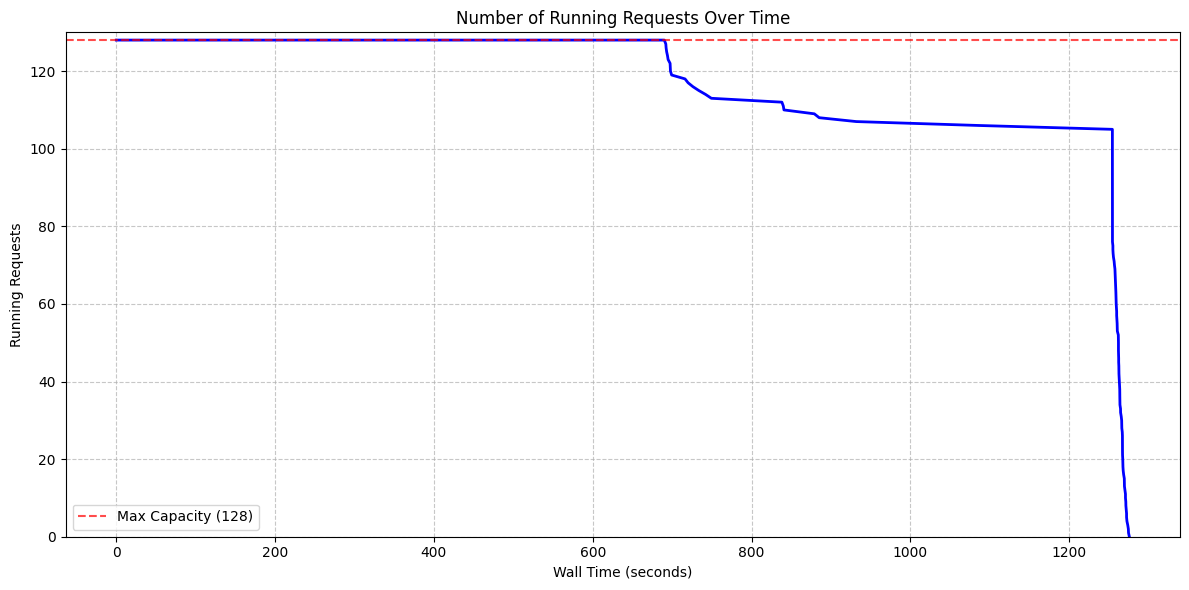

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Extract timestamps and remaining requests from queue_stat
timestamps = [stat[0] for stat in queue_stat]
remaining_requests = [stat[1] for stat in queue_stat]

# Convert to relative time (starting from 0)
start_time = timestamps[0]
relative_times = [t - start_time for t in timestamps]

# Calculate running requests (128 + remaining requests beyond 128)
# If remaining requests > 128, then we're at max capacity (128)
# Otherwise, we calculate 256 - remaining to get current running
running_requests = []
total_requests = 512

for remaining in remaining_requests:
    if remaining > 128:
        # We're at max capacity (128 running)
        running_requests.append(128)
    else:
        # Calculate actual running requests
        running_requests.append(remaining)

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(relative_times, running_requests, 'b-', linewidth=2)
plt.xlabel('Wall Time (seconds)')
plt.ylabel('Running Requests')
plt.title('Number of Running Requests Over Time')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 130)  # Set y-axis limits with a little headroom above 128

# Add horizontal line at max capacity (128)
plt.axhline(y=128, color='r', linestyle='--', alpha=0.7, label='Max Capacity (128)')

plt.legend()
plt.tight_layout()
plt.show()

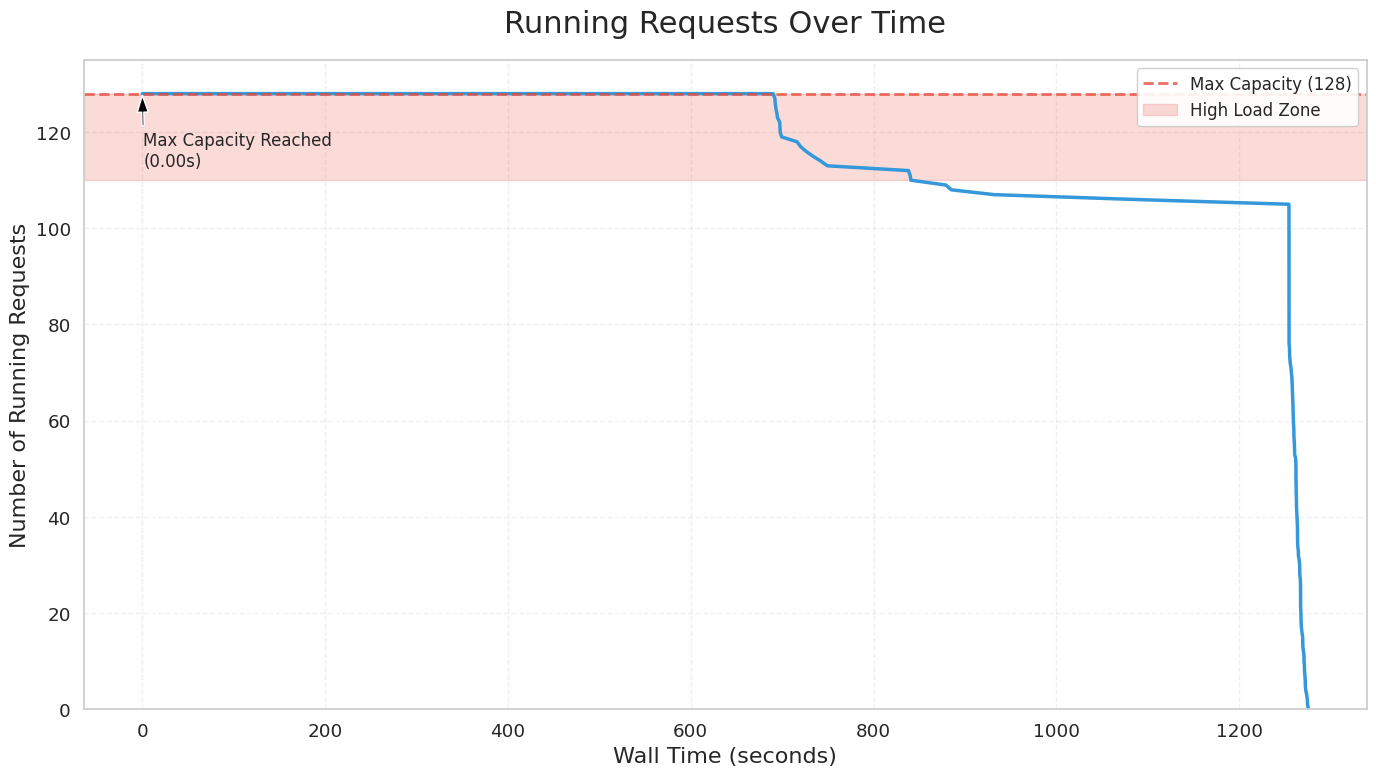

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set the Seaborn style and context
sns.set(style="whitegrid")
sns.set_context("notebook", font_scale=1.2)

# Create a DataFrame for better plotting with Seaborn
data = pd.DataFrame({
    'Wall Time (seconds)': relative_times,
    'Running Requests': running_requests
})

# Create the enhanced plot
plt.figure(figsize=(14, 8))
ax = sns.lineplot(
    data=data, 
    x='Wall Time (seconds)', 
    y='Running Requests',
    linewidth=2.5,
    color='#3498db'
)

# Add a horizontal line at max capacity
plt.axhline(y=128, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.8, label='Max Capacity (128)')

# Add shaded region to represent high load zone
plt.axhspan(110, 128, alpha=0.2, color='#e74c3c', label='High Load Zone')

# Enhance the plot appearance
plt.title('Running Requests Over Time', fontsize=22, pad=20)
plt.ylabel('Number of Running Requests', fontsize=16)
plt.xlabel('Wall Time (seconds)', fontsize=16)
plt.ylim(0, 135)

# Add annotations for key points
max_point_idx = np.argmax(running_requests)
max_point_x = relative_times[max_point_idx]
max_point_y = running_requests[max_point_idx]

if max_point_y == 128:
    # Find the first point where we hit max capacity
    max_indices = [i for i, val in enumerate(running_requests) if val == 128]
    if max_indices:
        max_point_idx = max_indices[0]
        max_point_x = relative_times[max_point_idx]
        plt.annotate(f'Max Capacity Reached\n({max_point_x:.2f}s)',
                    xy=(max_point_x, max_point_y),
                    xytext=(max_point_x + 1, max_point_y - 15),
                    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                    fontsize=12)

# Customize the legend
plt.legend(loc='upper right', frameon=True, framealpha=0.9, fontsize=12)

# Add grid but make it subtle
plt.grid(True, linestyle='--', alpha=0.3)

# Improve layout
plt.tight_layout()

# Show the plot
plt.show()

In [17]:
lengths = []
for _, v_ in output.items():
    for _, v in v_.items():
        lengths.append(len(v['meta_info']['output_token_logprobs']))
lengths

[16384,
 216,
 16384,
 123,
 19,
 16384,
 221,
 519,
 140,
 132,
 16384,
 98,
 7642,
 228,
 99,
 299,
 85,
 16384,
 16384,
 16384,
 16384,
 16384,
 16384,
 260,
 145,
 16384,
 130,
 16384,
 236,
 174,
 16384,
 16384,
 119,
 16384,
 18,
 16384,
 259,
 100,
 16384,
 16384,
 16384,
 6,
 5,
 132,
 16384,
 105,
 16384,
 157,
 110,
 216,
 16384,
 192,
 16384,
 168,
 17,
 179,
 579,
 193,
 16384,
 16384,
 219,
 16144,
 16384,
 16384,
 105,
 414,
 16384,
 16384,
 101,
 16384,
 725,
 212,
 17,
 203,
 105,
 16384,
 1377,
 107,
 2771,
 24,
 150,
 17,
 130,
 16384,
 188,
 16384,
 5991,
 16384,
 16384,
 159,
 16384,
 16384,
 16384,
 16384,
 16384,
 16384,
 306,
 100,
 16384,
 130,
 106,
 16384,
 5,
 16384,
 16384,
 16384,
 16384,
 16384,
 145,
 16384,
 16,
 16384,
 125,
 245,
 16384,
 16384,
 16384,
 16384,
 16384,
 16384,
 105,
 124,
 738,
 16384,
 16384,
 70,
 99,
 16384,
 16384,
 237,
 100,
 16384,
 98,
 10,
 105,
 182,
 16384,
 16384,
 16384,
 16384,
 16384,
 16384,
 3010,
 96,
 73,
 16384,
 98

In [23]:
torch.save(lengths, '/home/aiscuser/verl/scripts/lengths.pt')
torch.save(queue_stat, '/home/aiscuser/verl/scripts/queue_stat.pt')

# FSDP Checkpoint Conversion

This notebook demonstrates how to convert Fully Sharded Data Parallel (FSDP) checkpoints into a single consolidated model checkpoint.
We'll process checkpoints located at: `/mnt/blob/ckpts_bugfix/LogicRL-RPP/LLaMA3.1-8B-128-8-128-GS/global_step_320/actor/`

These checkpoints include:
- Model files: `model_world_size_4_rank_[0-3].pt`
- Extra state files: `extra_state_world_size_4_rank_[0-3].pt`
- Optimizer files: `optim_world_size_4_rank_[0-3].pt`

Our focus is merging the model weights, ignoring optimizer states.

In [1]:
import os
import torch
import glob
from collections import OrderedDict
import re
import shutil
from pathlib import Path
from accelerate.utils import merge_fsdp_weights

# Set FSDP checkpoint path
checkpoint_dir = "/mnt/blob/ckpts_bugfix/LogicRL-RPP/LLaMA3.1-8B-128-8-128-GS/global_step_320/actor/"
output_dir = "/tmp/merged_checkpoint/"
os.makedirs(output_dir, exist_ok=True)

/opt/conda/envs/ptca/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os, re, torch
from collections import defaultdict
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer

ckpt_dir   = "/mnt/blob/ckpts_bugfix/LogicRL-RPP/LLaMA3.1-8B-128-8-128-GS/global_step_320/actor"
base_model = "meta-llama/Llama-3.1-8B-Instruct"
out_dir    = "/tmp/Llama3.1-8B-step320-merged"

# -------- 1. load every rank checkpoint --------
regex   = re.compile(r"model_world_size_\d+_rank_(\d+)\.pt")
rank_sd = {}                              # rank → state-dict
for f in os.listdir(ckpt_dir):
    m = regex.match(f)
    if m:
        rank = int(m.group(1))
        rank_sd[rank] = torch.load(os.path.join(ckpt_dir, f), map_location="cpu")

world_size = len(rank_sd)
assert world_size > 0, "no rank files found"

# -------- 2. collect per-param slices --------
slices = defaultdict(list)                # param → [local_tensor per rank]
for rank in range(world_size):
    for k, v in rank_sd[rank].items():
        if isinstance(v, torch.distributed._tensor.DTensor):
            # grab the shard stored on this rank
            slices[k].append(v._local_tensor)     # private attr but works fine
        else:                                     # unsharded params / scalars
            slices[k] = [v] * world_size          # replicate so cat() is no-op

# -------- 3. reassemble full tensors --------
full = {}
for k, parts in slices.items():
    # if more than one shard, concatenate along dim 0
    full[k] = torch.cat(parts, dim=0) if len(parts) > 1 else parts[0]

# -------- 4. drop into an HF model and save --------
cfg   = AutoConfig.from_pretrained(base_model)
model = AutoModelForCausalLM.from_config(cfg)
model.load_state_dict(full, strict=False)
model.save_pretrained(out_dir)
AutoTokenizer.from_pretrained(base_model).save_pretrained(out_dir)

print("✅ merged checkpoint written to", out_dir)


/tmp/ipykernel_50592/866181160.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  rank_sd[rank] = torch.load(os.path.join(ckpt_dir, f), map_location="cpu")


[2025-05-10 10:32:54,760] [INFO] [real_accelerator.py:239:get_accelerator] Setting ds_accelerator to cuda (auto detect)


✅ merged checkpoint written to /tmp/Llama3.1-8B-step320-merged
